In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D

In [2]:
a = 1
rh = 1 + math.sqrt(1 - a**2) # Ορίζοντας γεγονότων σε μία KBH
print("rh = ",rh)

re = 2 # Συντεταγμένη που εντοπίζεται το Static Limit

rh =  1.0


**Ορισμός συναρτήσεων**

In [3]:
def gtt(r):
  return -(1 - (2/r))
def gtφ(r):
  return -2*a/r
def gφφ(r):
  return r**2 + a**2 + (2*(a**2))/r

def Δ(r):
  return r**2 - 2*r + a**2
def grr(r):
  return (r**2)/Δ(r)


**Αρχικές Συνθήκες**

In [4]:
r0 = 1.2
φ0 = 0

# Αρχική θέση του σωματιδίου
x0 = r0*np.cos(φ0)
y0 = r0*np.sin(φ0)

Στροφορμή του σωματιδίου

In [45]:
l =  -0.3
# Θετικό l
# l = ((r0**2) - 2*a*math.sqrt(r0) + a**2)/(((math.pow(r0,3/4))*math.sqrt((math.pow(r0,3/2))-3*math.sqrt(r0)+2*a)))
# print("l = ",l)

# Αρνητικό l
# l = -((r0**2) + 2*a*math.sqrt(r0) + a**2)/(((math.pow(r0,3/4))*math.sqrt((math.pow(r0,3/2))-3*math.sqrt(r0)-2*a)))
# print("l = ",l)

Ορισμός των δυναμικών V+ και V- που είχαμε για την κίνηση των φωτονίων

In [46]:
def V1ph(r):
  return ((2*r*a + (r**2)*np.sqrt(Δ(r)))/((r**2+a**2)**2 - a**2*Δ(r)))*l

def V2ph(r):
  return (2*r*a - r**2*np.sqrt(Δ(r)))*l/((r**2+a**2)**2 - a**2*Δ(r))

def g(r):
  return ((r**2*Δ(r))/((r**2 + a**2)**2 - a**2*Δ(r))) - V1ph(r)*V2ph(r)

**Ορισμός των δυναμικών για τα σωματίδια**

In [47]:
def V1(r):
  return (V1ph(r)+V2ph(r)+np.sqrt((V1ph(r)+V2ph(r))**2 + 4*g(r)))/2

In [48]:
def V2(r):
  return (V1ph(r)+V2ph(r)-np.sqrt((V1ph(r)+V2ph(r))**2 + 4*g(r)))/2

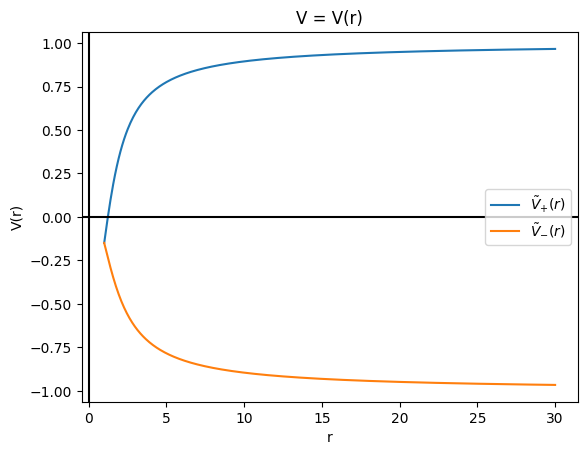

In [49]:
x_values = np.linspace(rh, 30, 500)
y_values = V1(x_values)

x_values2 = np.linspace(rh, 30, 500)
y_values2 = V2(x_values2)

yvalues = V1ph(x_values)
yvalues2 = V2ph(x_values2)

plt.plot(x_values, y_values, label = r'$\tilde{V}_{+}(r)$')
plt.plot(x_values2, y_values2, label = r'$\tilde{V}_{-}(r)$')

# plt.plot(x_values, yvalues, label = r'$V_{+}(r)$', color = "red")
# plt.plot(x_values2, yvalues2, label = r'$V_{-}(r)$', color = "black")

plt.xlabel('r')
plt.ylabel('V(r)')
plt.title('V = V(r)')
plt.axhline(0, color='black')
plt.axvline(0, color='black')
# plt.axhline(1, color = 'red')
# plt.axhline(0.9, color = 'red')
#plt.axis("equal")
#plt.xlim(2,2.3)
plt.legend()

**Ενέργεια σωματιδίου**

In [68]:
e = -0.0000001
# # Θετικό l
# e = ((math.pow(r0,3/2)) - (2*math.sqrt(r0)) + a)/(((math.pow(r0,3/4))*math.sqrt((math.pow(r0,3/2))-3*math.sqrt(r0)+2*a))) +0.0000000000001
# print("e = ",e)

# # Αρνητικό l
# # e = ((math.pow(r0,3/2)) - (2*math.sqrt(r0)) - a)/(((math.pow(r0,3/4))*math.sqrt((math.pow(r0,3/2))-3*math.sqrt(r0)-2*a))) +0.0000000000001
# # print("e = ",e)

In [69]:
# Συντεταγμένη r στην οποία έχουμε την αλλάγη προσήμου της γωνιακής ταχύτητας του σωματιδίου
# a = 0.99
# l = -5
# e = 1.1
rtpφ = 2*(1-(a*e/l))
print("rtpφ = ", rtpφ)

rtpφ =  1.9999993333333332


V = V(r) με τα e και rtpφ

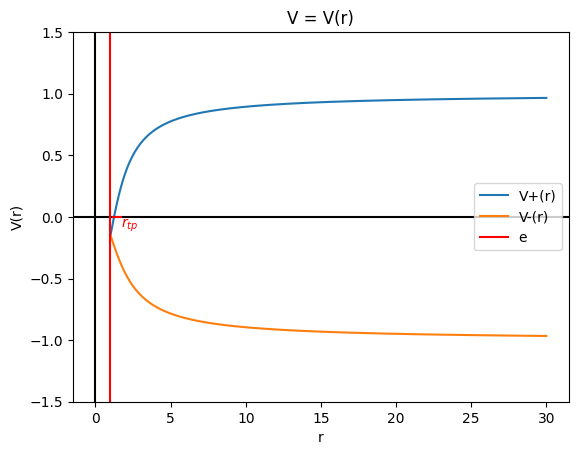

In [70]:
plt.plot(x_values, y_values, label = 'V+(r)')
plt.plot(x_values2, y_values2, label = 'V-(r)')

#plt.plot(x_values, yvalues, label = 'V+ph(r)', color = "red")
#plt.plot(x_values2, yvalues2, label = 'V-ph(r)', color = "black")

plt.xlabel('r')
plt.ylabel('V(r)')
plt.title('V = V(r)')
plt.axhline(0, color='black')
plt.axvline(0, color='black')
# plt.axhline(e, color = 'red')
plt.plot([r0, 1.7], [e, e], color='red', linestyle='-', label = 'e')
plt.plot([1.7, 1.7], [0,e], color='red', linestyle='--')
plt.text(1.7, 0, r'$r_{tp}$', color='red', ha='left', va='top')
# plt.plot([8.03, 8.03], [0,e], color='red', linestyle='--')
# plt.text(8.03, 0, r'$r_{tp_{2}}$', color='red', ha='left', va='top')
# plt.axvline(rtpφ, color='pink')
#plt.axis("equal")
plt.ylim(-1.5,1.5)
plt.axvline(rh, color='red')
plt.legend()

Αν k = -1, το σωματίδιο αρχικά οδεύει προς την μαύρη τρύπα, ενώ
αν k = +1, το σωματίδιο αρχικά οδεύει μακριά από τη μαύρη τρύπα.

In [71]:
k = +1

In [72]:
def f1(r):
  return k*math.sqrt((((r**2+a**2)**2 - a**2*Δ(r))/r**4)*(e - V1(r))*(e - V2(r)))

def f2(r):
  return -(gtt(r)*l + gtφ(r)*e)/(Δ(r))

Υπολογισμός των ποσότητων uφ0 και ut0

In [73]:
ut0 = (gφφ(r0)*e + gtφ(r0)*l)/Δ(r0)
uφ0 = -(gtt(r0)*l + gtφ(r0)*e)/Δ(r0)

print("ut0 = ",ut0)
print("uφ0 = ",uφ0)

ut0 =  12.499989733333322
uφ0 =  4.99999583333333


In [44]:
# Eπιβεβαιώση της σχέσης u u = -1 και υπολογισμός της αρχικής ακτινικής ταχύτητας
#Έχοντας επιλέξει σωστά την ενέργεια του φωτονίου αναλογιζόμενοι το διάγραμμα, δεν περιμένουμε
#να μας εμφανίσει error. Αν όμως εμφανιστεί, αρκεί να αλλάξουμε την ενέργεια.

u2  = -(1 + gtt(r0)*(ut0**2) + gφφ(r0)*(uφ0**2) + 2*gtφ(r0)*ut0*uφ0)/(grr(r0))
if u2 > 0:
  ur0 = math.sqrt(u2)
  if ur0 < 1:
    print("ur0 = ",ur0)
  else:
    print("ERROR, radial velocity is larger than the speed of light")
else:
  print(u2)
  print("ERROR, change the energy")

ERROR, radial velocity is larger than the speed of light


In [ ]:
b1 = 0   #Aρχική χρονική στιγμή του σωματιδίου
b2 = 350 #Τελική χρονική στιγμή του σωματιδίου

dt = 0.01 #Χρονικό βήμα

N = int((b2-b1)/dt) #Αριθμός βημάτων

# Λίστες

r = [0]*(N+1)
φ = [0]*(N+1)
τ = [0]*(N+1)

# Αρχικές συνθήκες

r[0] = r0
φ[0] = φ0
τ[0] = b1

rstop = rh + 0.01 # Η απόσταση από το κέντρο της μαύρης τρύπας που θα σταματήσει η επανάληψη της RK4. Στην προκειμένη περίπτωση η απόσταση αυτή θέλω να είναι ο ορίζοντας της KBH

**Runge Kutta για την λύση της f1(r)**

Text(0.5, 1.0, 'Διάγραμμα r = r(τ)')

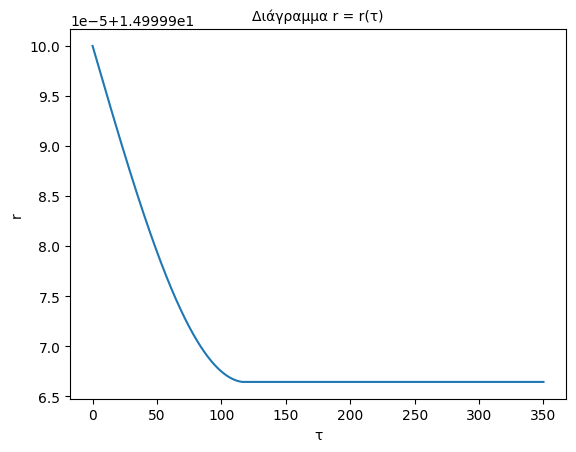

In [ ]:
k1 = 0
k2 = 0
k3 = 0
k4 = 0

c = 1

for i in range(N):
  if (e - V1(r[i]+k3)) > 0:
    if r[i] > rstop:

        k1 = c*dt*f1(r[i])
        k2 = c*dt*f1(r[i] + 0.5*k1)
        k3 = c*dt*f1(r[i] + 0.5*k2)
        k4 = c*dt*f1(r[i] + k3)

        r[i+1] = r[i] + (k1 + 2*k2 + 2*k3 + k4)/6
        τ[i+1] = τ[i] + dt
    else:
        r[i+1] = r[i]
        τ[i+1] = τ[i] + dt

  else:
      c = -c

      k1 = c*dt*f1(r[i])
      k2 = c*dt*f1(r[i] + 0.5*k1)
      k3 = c*dt*f1(r[i] + 0.5*k2)
      k4 = c*dt*f1(r[i] + k3)


      r[i+1] = r[i] + (k1 + 2*k2 + 2*k3 + k4)/6
      τ[i+1] = τ[i] + dt

plt.plot(τ, r)
plt.xlabel('τ')
plt.ylabel('r')
plt.title('Διάγραμμα r = r(τ)', fontsize = 10)
# plt.axhline(8.03, color = 'red')
# plt.axhline(1.37, color = 'red')


**Runge Kutta για την λύση της f2(r)**



In [ ]:
k1 = 0
k2 = 0
k3 = 0
k4 = 0

for i in range(N):
  if r[i] > rstop:
    k1 = dt*f2(r[i])
    k2 = dt*f2((r[i] + r[i+1])/2)
    k3 = k2
    k4 = dt*f2(r[i+1])

    φ[i+1] = φ[i] + (k1 + 2*k2 + 2*k3 + k4)/6

  else:
    φ[i+1] = φ[i]


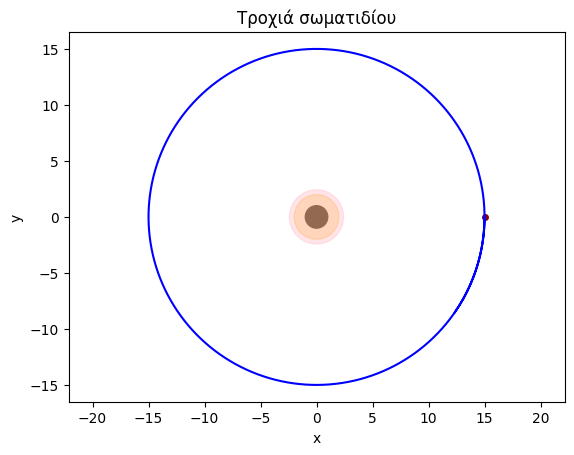

In [ ]:
x = [0]*(N)
y = [0]*(N)

for i in range(N):
  x[i] = r[i]*math.cos(φ[i])
  y[i] = r[i]*math.sin(φ[i])

circle1 = plt.Circle((0, 0), rh, color='black', alpha = 1)
circle2 = plt.Circle((0, 0), 2, color='orange', alpha = 0.3)
circle3 = plt.Circle((0, 0), rtpφ, color='pink', alpha = 0.4)

plt.gca().add_artist(circle1)
plt.gca().add_artist(circle2)
plt.gca().add_artist(circle3)
plt.plot(x0, y0, 'o', color='darkred', markersize = '4')
plt.plot(x,y,color = 'blue')
plt.title("Τροχιά σωματιδίου")
plt.axis("equal")
plt.xlabel('x')
plt.ylabel('y')
# plt.xlim(-3,17)
plt.show()

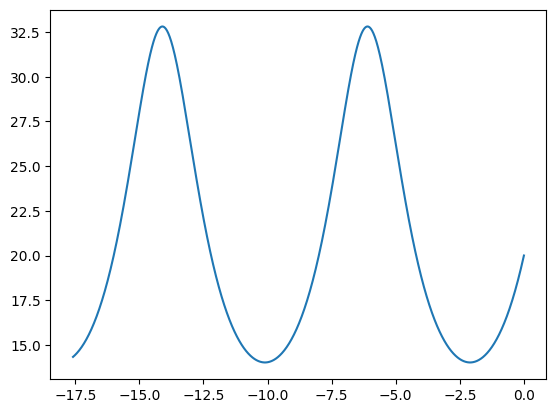

In [ ]:
plt.plot(φ,r)

In [ ]:
# 1) Κλειστή τροχιά #2 (με αρνητικό l)
# Διάφορες τροχιές
# a = 0.8
# r0 = 20, φ0 = 0
# l = -5, e = 0.98
# b2 = 1700

# Κλειστη τροχιά #1 (με θετικό l)
# a = 0.99
# r0 = 5
# φ0 = 0
# l = 2
# e = 0.9
# β2 = 200